# Week2_Bonus

## Warm_UP

In [1]:
import pandas as pd
from sklearn.datasets import load_diabetes
diabete = load_diabetes(scaled=False)
df = pd.DataFrame(data=diabete.data, columns=diabete.feature_names)
df['target'] = diabete.target
y=diabete.target
print("Shape of  data:", df.shape)

Shape of  data: (442, 11)


In [11]:
print(df.iloc[:10])

    age  sex   bmi     bp     s1     s2    s3    s4      s5    s6  target
0  59.0  2.0  32.1  101.0  157.0   93.2  38.0  4.00  4.8598  87.0   151.0
1  48.0  1.0  21.6   87.0  183.0  103.2  70.0  3.00  3.8918  69.0    75.0
2  72.0  2.0  30.5   93.0  156.0   93.6  41.0  4.00  4.6728  85.0   141.0
3  24.0  1.0  25.3   84.0  198.0  131.4  40.0  5.00  4.8903  89.0   206.0
4  50.0  1.0  23.0  101.0  192.0  125.4  52.0  4.00  4.2905  80.0   135.0
5  23.0  1.0  22.6   89.0  139.0   64.8  61.0  2.00  4.1897  68.0    97.0
6  36.0  2.0  22.0   90.0  160.0   99.6  50.0  3.00  3.9512  82.0   138.0
7  66.0  2.0  26.2  114.0  255.0  185.0  56.0  4.55  4.2485  92.0    63.0
8  60.0  2.0  32.1   83.0  179.0  119.4  42.0  4.00  4.4773  94.0   110.0
9  29.0  1.0  30.0   85.0  180.0   93.4  43.0  4.00  5.3845  88.0   310.0


In [12]:
print(df.dtypes)

age       float64
sex       float64
bmi       float64
bp        float64
s1        float64
s2        float64
s3        float64
s4        float64
s5        float64
s6        float64
target    float64
dtype: object


In [13]:
print(df.isnull().sum())

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64


__we don't have any missing value in dataframe.__

In [15]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_normalized = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

print("Min-Max Normalized DataFrame:")
print(df_normalized)

Min-Max Normalized DataFrame:
          age  sex       bmi        bp        s1        s2        s3  \
0    0.666667  1.0  0.582645  0.549296  0.294118  0.256972  0.207792   
1    0.483333  0.0  0.148760  0.352113  0.421569  0.306773  0.623377   
2    0.883333  1.0  0.516529  0.436620  0.289216  0.258964  0.246753   
3    0.083333  0.0  0.301653  0.309859  0.495098  0.447211  0.233766   
4    0.516667  0.0  0.206612  0.549296  0.465686  0.417331  0.389610   
..        ...  ...       ...       ...       ...       ...       ...   
437  0.683333  1.0  0.421488  0.704225  0.431373  0.359562  0.259740   
438  0.466667  1.0  0.285124  0.183099  0.627451  0.619522  0.259740   
439  0.683333  1.0  0.285124  0.530563  0.318627  0.323705  0.272727   
440  0.283333  0.0  0.495868  0.464789  0.509804  0.416335  0.259740   
441  0.283333  0.0  0.066116  0.126761  0.750000  0.456175  0.974026   

           s4        s5        s6    target  
0    0.282087  0.562217  0.439394  0.392523  
1    0.141044

In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y,  test_size=0.05,  random_state=1  )

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

Training set size: 419
Testing set size: 23


In [17]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (419, 10)
X_test shape: (23, 10)
y_train shape: (419,)
y_test shape: (23,)


## Main Task

### part1

In [18]:
def mse_calculate(y_true, y_pred):
    mse = sum((i - j) ** 2 for i, j in zip(y_true, y_pred)) / len(y_true)
    return mse

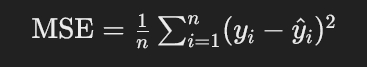

In [19]:
def mae_calculate(y_true, y_pred):
    mae = sum(abs(i - j) for i, j in zip(y_true, y_pred)) / len(y_true)
    return mae

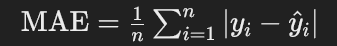

In [20]:
import math

def rmse_calculate(y_true, y_pred):
    mse = mse_calculate(y_true, y_pred)
    rmse = math.sqrt(mse)
    return rmse

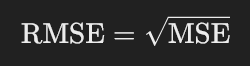

In [21]:
def r_squared(y_true, y_pred):
   
    mean_y_true = sum(y_true) / len(y_true) 
    b = sum((y - mean_y_true) ** 2 for y in y_true)
    a = sum((i - j) ** 2 for i, j in zip(y_true, y_pred))
    return  1-(a/b)

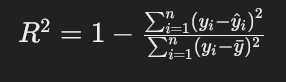

### part2

In [31]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
mse = mse_calculate(y_test, y_pred)
mae = mae_calculate(y_test, y_pred)
rmse = rmse_calculate(y_test, y_pred)
r2 = r_squared(y_test, y_pred)

In [32]:
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Mean Squared Error: 3096.028307344242
Mean Absolute Error: 43.581693254652485
Root Mean Squared Error: 55.64196534401209
R² Score: 0.41563993364080565


### part3

In [ ]:

from sklearn.preprocessing import StandardScaler, PolynomialFeatures
import numpy as np

poly_model = LinearRegression()
poly_model.fit(X_train, y_train)

y_poly_pred = poly_model.predict(X_test)

mse_poly = mse_calculate(y_test, y_poly_pred)
mae_poly = mae_calculate(y_test, y_poly_pred)
rmse_poly = rmse_calculate(y_test, y_poly_pred)
r2_poly = r_squared(y_test, y_poly_pred)

In [34]:
print("Polynomial Regression Mean Squared Error:", mse_poly)
print("Polynomial Regression Mean Absolute Error:", mae_poly)
print("Polynomial Regression Root Mean Squared Error:", rmse_poly)
print("Polynomial Regression R² Score:", r2_poly)

Polynomial Regression Mean Squared Error: 3096.0283073442424
Polynomial Regression Mean Absolute Error: 43.581693254652485
Polynomial Regression Root Mean Squared Error: 55.64196534401209
Polynomial Regression R² Score: 0.41563993364080565


### Comparison of Polynomial Regression and Linear Regression

#### Polynomial Regression
- **Mean Squared Error (MSE):** 3096.03
- **Mean Absolute Error (MAE):** 43.58
- **Root Mean Squared Error (RMSE):** 55.64
- **R² Score:** 0.416

#### Linear Regression
- **Mean Squared Error (MSE):** 3096.03
- **Mean Absolute Error (MAE):** 43.58
- **Root Mean Squared Error (RMSE):** 55.64
- **R² Score:** 0.416

In [36]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

mse_train = mse_calculate(y_train, y_train_pred)
mae_train = mae_calculate(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r_squared(y_train, y_train_pred)

mse_test = mse_calculate(y_test, y_test_pred)
mae_test = mae_calculate(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r_squared(y_test, y_test_pred)

print("Training Set Metrics:")
print("Mean Squared Error (MSE):", mse_train)
print("Mean Absolute Error (MAE):", mae_train)
print("Root Mean Squared Error (RMSE):", rmse_train)
print("R² Score:", r2_train)

print("\n\nTesting Set Metrics:")
print("Mean Squared Error (MSE):", mse_test)
print("Mean Absolute Error (MAE):", mae_test)
print("Root Mean Squared Error (RMSE):", rmse_test)
print("R² Score:", r2_test)


Training Set Metrics:
Mean Squared Error (MSE): 2393.1386180597856
Mean Absolute Error (MAE): 39.14260998957731
Root Mean Squared Error (RMSE): 48.91971604639366
R² Score: 0.6061583502354682


Testing Set Metrics:
Mean Squared Error (MSE): 3096.0283073442424
Mean Absolute Error (MAE): 43.581693254652485
Root Mean Squared Error (RMSE): 55.64196534401209
R² Score: 0.41563993364080565


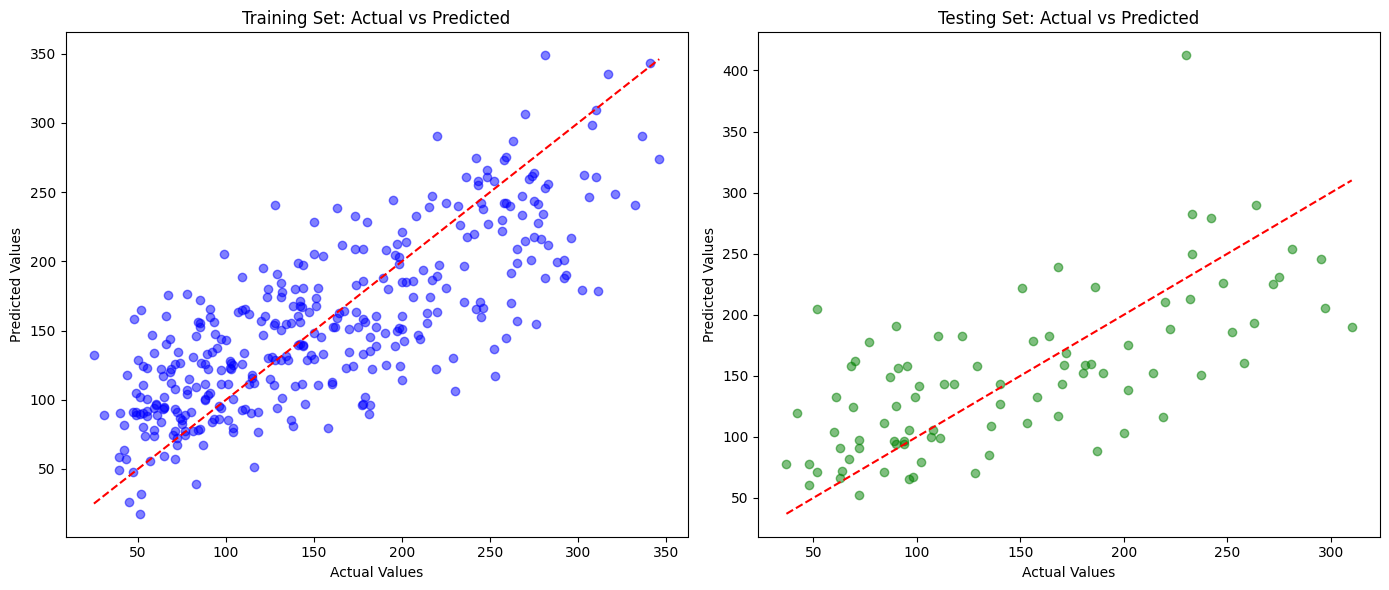

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))


plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_pred, alpha=0.5, color='blue')
plt.title('Training Set: Actual vs Predicted')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test_pred, alpha=0.5, color='green')
plt.title('Testing Set: Actual vs Predicted')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')

plt.tight_layout()
plt.show()

### Result

| Data Type/Optimizer | MSE     | MAE     | RMSE    | R² Score |
|---------------------|---------|---------|---------|----------|
| Train Set           | 2393.13 | 39.14 | 48.91 | 0.60 |
| Test Set            | 3096.02  | 43.58  | 55.64  | 0.41  |
